# <p style="text-align: center;">Multiclass Image Classification Using CNN</p>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1. Import the Required Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import cv2
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

### **2. Load the Image Training and Validation Datasets**

#### **i. Get the Image Dataset Paths**

In [3]:
train_dataset_path = '/content/drive/MyDrive/Blood Cancer -4 Class Splited/train'
validation_dataset_path = '/content/drive/MyDrive/Blood Cancer -4 Class Splited/val'

#### **ii. Load Image Datasets and Apply Augmentations**

Since the images present in the datasets are 150x150px in size, the image height and width are taken as 150, 150 respectively. The batch size value can be changed if required.

In [4]:
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

Loading the training dataset and applying augmentations on it.

In [5]:
train_datagen = ImageDataGenerator(rescale=1.0/255,
                                  zoom_range=0.2,
                                  width_shift_range=0.2,
                                  height_shift_range=0.2,
                                  fill_mode='nearest')
train_generator = train_datagen.flow_from_directory(train_dataset_path,
                                                   target_size=(IMG_WIDTH, IMG_HEIGHT),
                                                   batch_size=BATCH_SIZE,
                                                   class_mode='categorical',
                                                   shuffle=True)

Found 2276 images belonging to 4 classes.


Loading the validation dataset.

In [6]:
validation_datagen = ImageDataGenerator(rescale=1.0/255)
validation_generator = validation_datagen.flow_from_directory(validation_dataset_path,
                                                             target_size=(IMG_WIDTH, IMG_HEIGHT),
                                                             batch_size=BATCH_SIZE,
                                                             class_mode='categorical',
                                                             shuffle=True)

Found 490 images belonging to 4 classes.


#### **iii. Get the Label Mappings**

The labels dictionary is made in order to retrive the class names against the label indices used for training the model

In [7]:
labels = {value: key for key, value in train_generator.class_indices.items()}

print("Label Mappings for classes present in the training and validation datasets\n")
for key, value in labels.items():
    print(f"{key} : {value}")

Label Mappings for classes present in the training and validation datasets

0 : Benign
1 : Early
2 : Pre
3 : Pro


### **3. Plotting Sample Training Images**

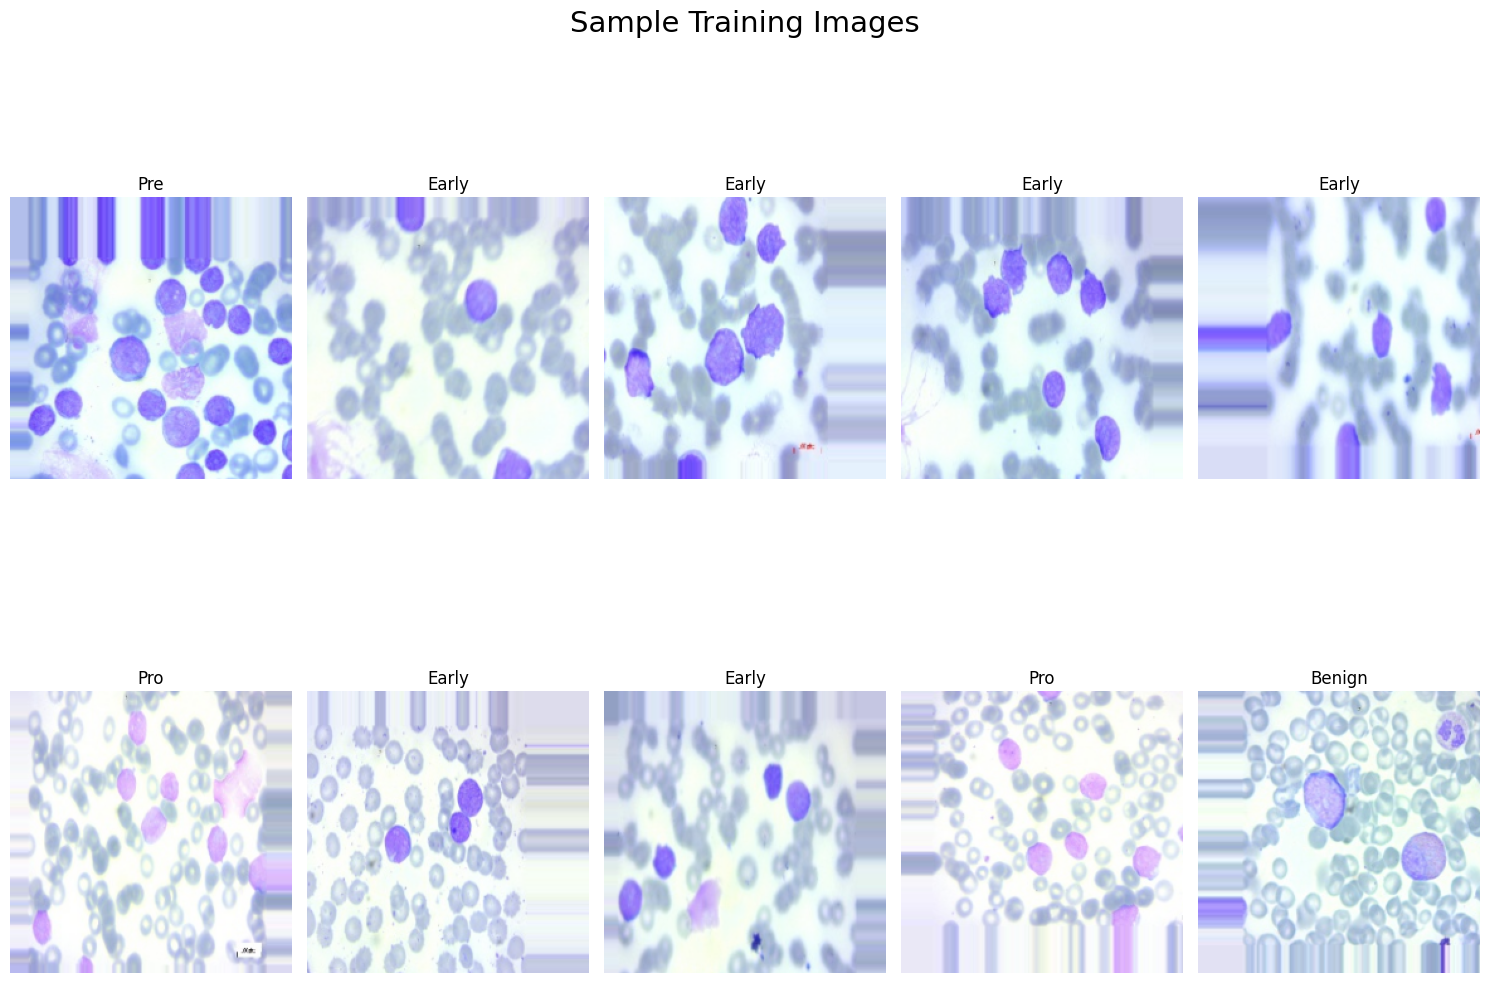

In [8]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 12))
idx = 0

for i in range(2):
    for j in range(5):
        label = labels[np.argmax(train_generator[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_generator[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

### **4. Training a CNN Model**

Since the training dataset is ready let's create a simple CNN Model to train on the image datasets

#### **i. Create a CNN Model**

In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, GlobalMaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

IMG_WIDTH, IMG_HEIGHT = 224, 224  # Set appropriate image dimensions
  # Adjust based on the number of classes

def create_model():
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), pooling='max')

    # Unfreeze all layers of the base model
    base_model.trainable = True

    model = Sequential([
        base_model,
        BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
        Dense(256, kernel_regularizer=regularizers.l2(0.016), activity_regularizer=regularizers.l1(0.006),
              bias_regularizer=regularizers.l1(0.006), activation='relu'),
        Dropout(rate=0.45, seed=123),
        Dense(4, activation='softmax')
    ])

    return model




In [13]:
cnn_model = create_model()

94765736/94765736 [==============================] - 1s 0us/step


In [14]:
print(cnn_model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 batch_normalization (Batch  (None, 2048)              8192      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 24121476 (92.02 MB)
Trainable params: 24064260 (91.80 MB)
Non-trainable params: 57216 (223.50 KB)
__________

#### **ii. Defining Callbacks**

A callback is an object that can perform actions at various stages of training (e.g. at the start or end of an epoch, before or after a single batch, etc)

#### **a. Reduce Learning Rate on Plateau**

Is used to reduce the learning rate when a metric has stopped improving.

In [15]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=np.sqrt(0.1), patience=5)

#### **iii. Defining the Optimizer**

In [16]:
optimizer = Adam(learning_rate=0.001)

#### **iv. Compile the Model**

In [17]:
cnn_model.compile(optimizer=optimizer, loss=CategoricalCrossentropy(), metrics=['accuracy'])

#### **v. Training the Model**

In [18]:
history = cnn_model.fit(train_generator, epochs=25, validation_data=validation_generator,
                       verbose=2,
                       callbacks=[reduce_lr])

Epoch 1/25
72/72 - 946s - loss: 6.7896 - accuracy: 0.8910 - val_loss: 5.8881 - val_accuracy: 0.2469 - lr: 0.0010 - 946s/epoch - 13s/step
Epoch 2/25
72/72 - 48s - loss: 4.4738 - accuracy: 0.8572 - val_loss: 172547.9062 - val_accuracy: 0.2959 - lr: 0.0010 - 48s/epoch - 672ms/step
Epoch 3/25
72/72 - 46s - loss: 2.3501 - accuracy: 0.9218 - val_loss: 29.1565 - val_accuracy: 0.2959 - lr: 0.0010 - 46s/epoch - 635ms/step
Epoch 4/25
72/72 - 46s - loss: 1.2580 - accuracy: 0.9666 - val_loss: 2.3167 - val_accuracy: 0.2959 - lr: 0.0010 - 46s/epoch - 634ms/step
Epoch 5/25
72/72 - 46s - loss: 0.7742 - accuracy: 0.9776 - val_loss: 2.5978 - val_accuracy: 0.2959 - lr: 0.0010 - 46s/epoch - 637ms/step
Epoch 6/25
72/72 - 46s - loss: 0.6169 - accuracy: 0.9754 - val_loss: 3.0490 - val_accuracy: 0.2959 - lr: 0.0010 - 46s/epoch - 642ms/step
Epoch 7/25
72/72 - 46s - loss: 0.8184 - accuracy: 0.9508 - val_loss: 1.9820 - val_accuracy: 0.2959 - lr: 0.0010 - 46s/epoch - 635ms/step
Epoch 8/25
72/72 - 45s - loss: 1.07

### **5. Plotting the Model Metrics**

#### **i. Plotting training and validation accuracy, loss and learning rate**

In [19]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

learning_rate = history.history['lr']

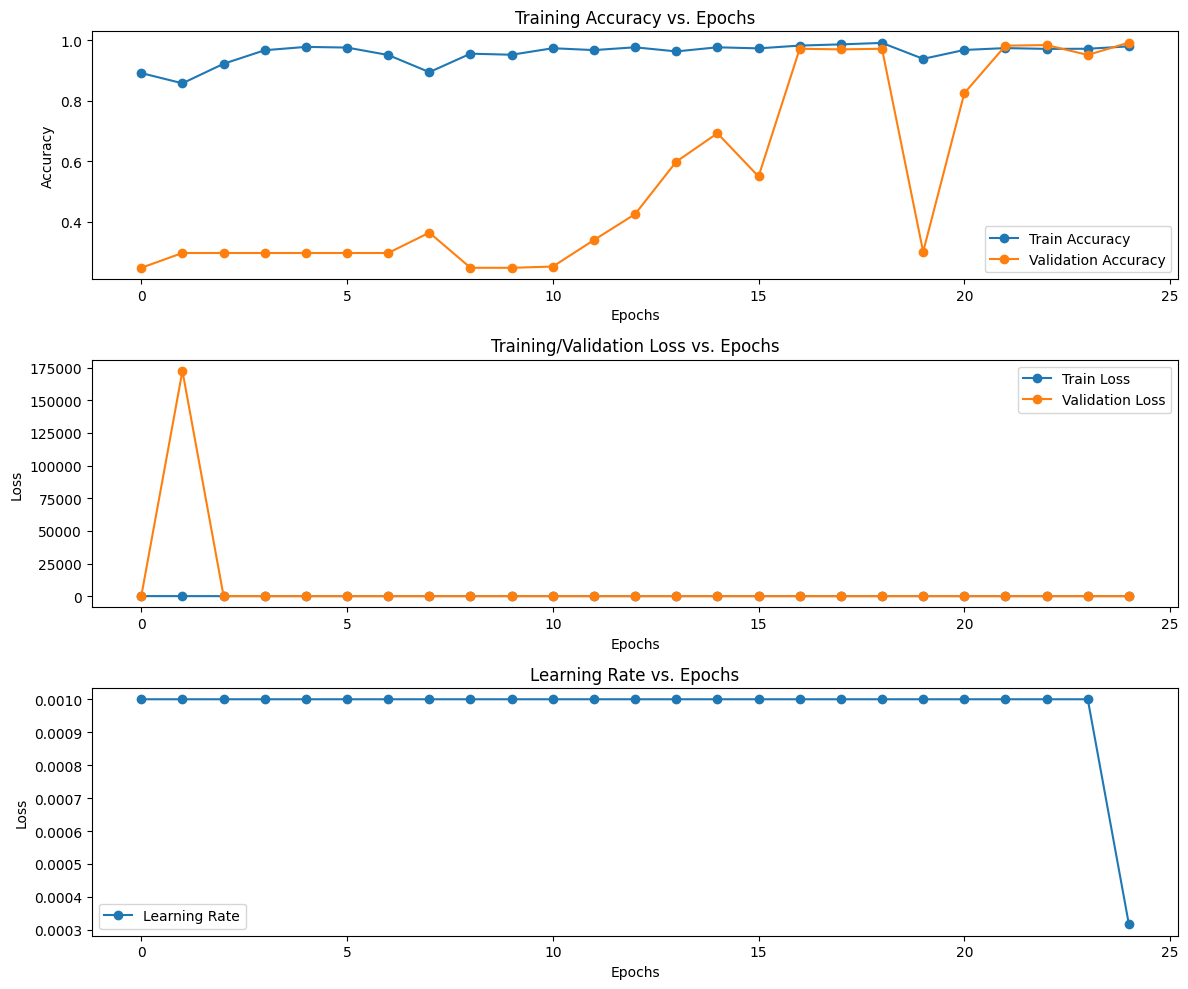

In [20]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 10))

ax[0].set_title('Training Accuracy vs. Epochs')
ax[0].plot(train_accuracy, 'o-', label='Train Accuracy')
ax[0].plot(val_accuracy, 'o-', label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='best')

ax[1].set_title('Training/Validation Loss vs. Epochs')
ax[1].plot(train_loss, 'o-', label='Train Loss')
ax[1].plot(val_loss, 'o-', label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='best')

ax[2].set_title('Learning Rate vs. Epochs')
ax[2].plot(learning_rate, 'o-', label='Learning Rate')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Loss')
ax[2].legend(loc='best')

plt.tight_layout()
plt.show()

### **6. Testing the Model on Test Set**

Testing the model on the validation dataset because a seperate dataset for testing is not available.

In [21]:
test_dataset = '/content/drive/MyDrive/Blood Cancer -4 Class Splited/test'

In [22]:
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(test_dataset,
                                                 shuffle=False,
                                                 batch_size=BATCH_SIZE,
                                                 target_size = (IMG_WIDTH, IMG_HEIGHT),
                                                 class_mode='categorical')

Found 490 images belonging to 4 classes.


### **7. Model Prediction on the Test Dataset**

In [23]:
predictions = cnn_model.predict(test_generator)

16/16 [==============================] - 129s 9s/step


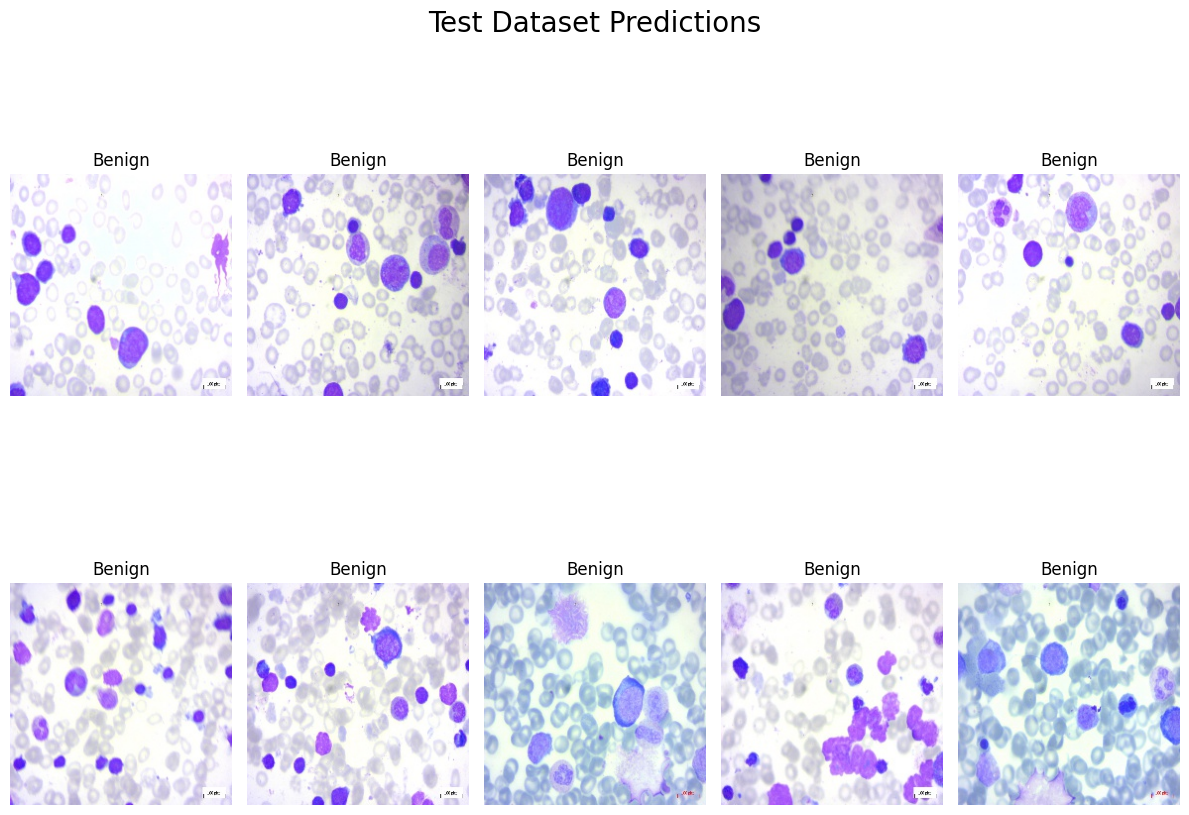

In [24]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(12, 10))
idx = 0

for i in range(2):
    for j in range(5):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[0][0][idx])
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [25]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator, batch_size=BATCH_SIZE)

16/16 [==============================] - 2s 141ms/step - loss: 0.1977 - accuracy: 1.0000


In [26]:
print(f"Test Loss:     {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Test Loss:     0.19774474203586578
Test Accuracy: 1.0


The test loss and test accuracy is the same as validation loss and validation accuracy at the last step since the testing and validation datasets are same.

### **8. Plotting the Classification Metrics**

### **i. Confusion Matrix**

In [27]:
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

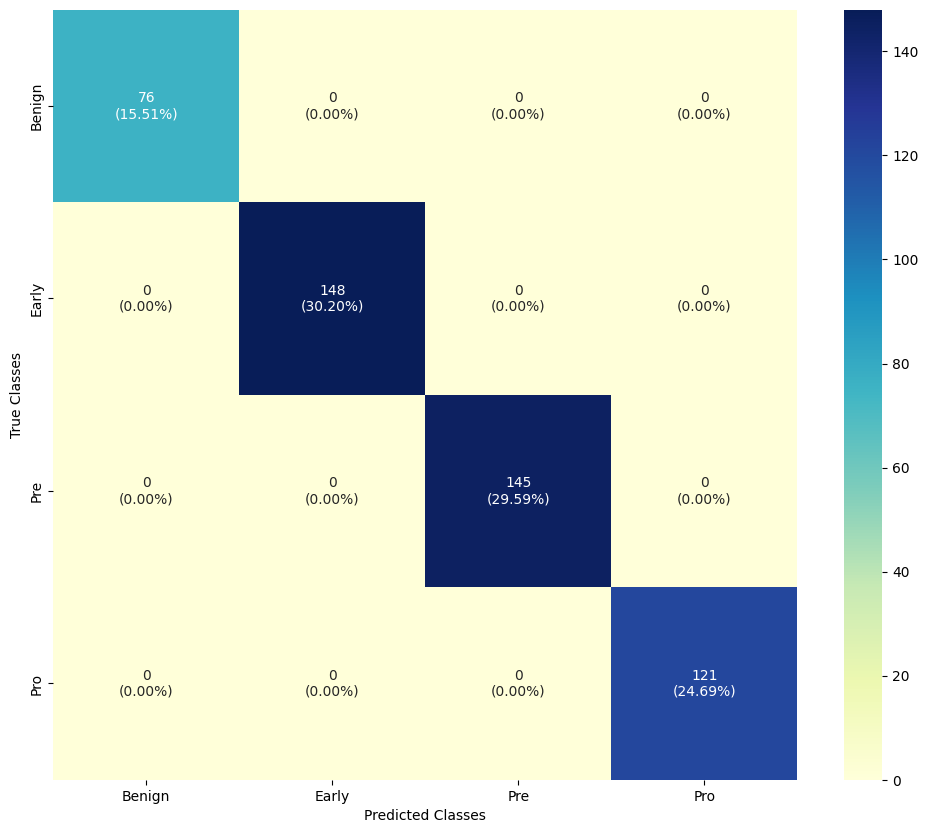

In [28]:
cf_mtx = confusion_matrix(y_true, y_pred)

group_counts = ["{0:0.0f}".format(value) for value in cf_mtx.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cf_mtx.flatten()/np.sum(cf_mtx)]
box_labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
box_labels = np.asarray(box_labels).reshape(4, 4)

plt.figure(figsize = (12, 10))
sns.heatmap(cf_mtx, xticklabels=labels.values(), yticklabels=labels.values(),
           cmap="YlGnBu", fmt="", annot=box_labels)
plt.xlabel('Predicted Classes')
plt.ylabel('True Classes')
plt.show()

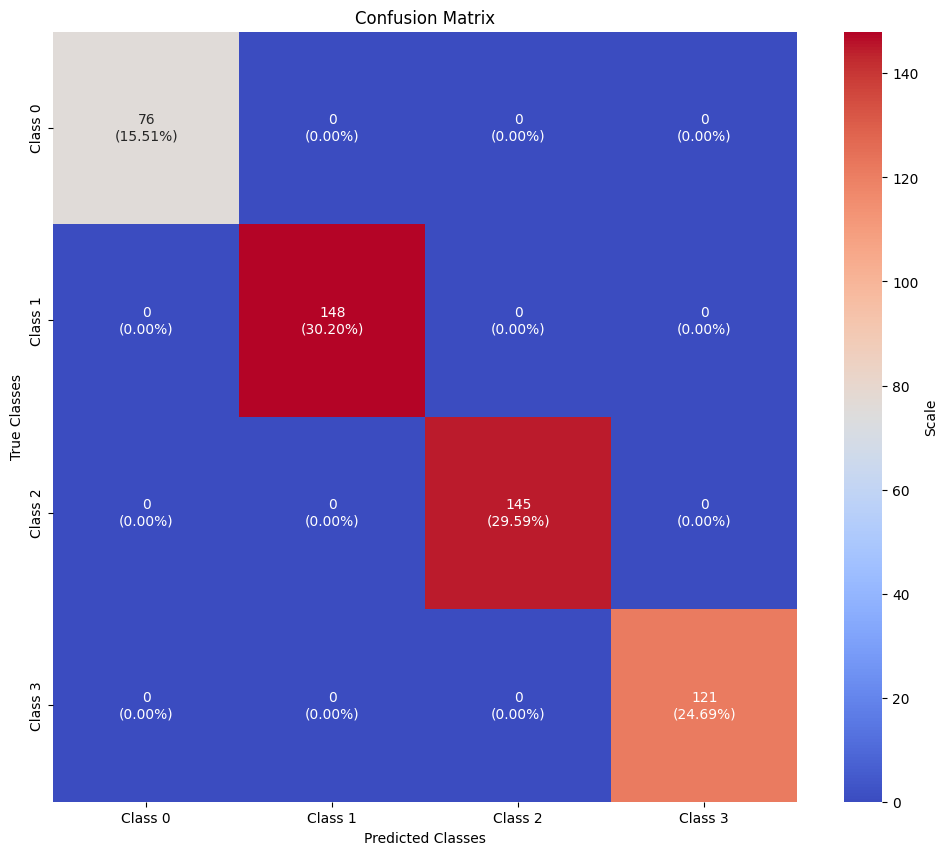

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming you have true labels and predicted labels
# y_true = ...
# y_pred = ...

# Define class labels
labels = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}

# Generate confusion matrix
cf_mtx = confusion_matrix(y_true, y_pred)

# Calculate counts and percentages
group_counts = ["{0:0.0f}".format(value) for value in cf_mtx.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cf_mtx.flatten()/np.sum(cf_mtx)]
box_labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
box_labels = np.asarray(box_labels).reshape(4, 4)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cf_mtx, annot=box_labels, fmt="", cmap="coolwarm", xticklabels=labels.values(), yticklabels=labels.values(), cbar_kws={'label': 'Scale'})
plt.title('Confusion Matrix')
plt.xlabel('Predicted Classes')
plt.ylabel('True Classes')
plt.show()


In [30]:
print(classification_report(y_true, y_pred, target_names=labels.values()))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        76
     Class 1       1.00      1.00      1.00       148
     Class 2       1.00      1.00      1.00       145
     Class 3       1.00      1.00      1.00       121

    accuracy                           1.00       490
   macro avg       1.00      1.00      1.00       490
weighted avg       1.00      1.00      1.00       490



### **9. Wrong Predictions**

Let's see where the model has given wrong predictions and what were the actual predictions on those images.

In [31]:
errors = (y_true - y_pred != 0)
y_true_errors = y_true[errors]
y_pred_errors = y_pred[errors]

In [32]:
test_images = test_generator.filenames
test_img = np.asarray(test_images)[errors]

ValueError: high <= 0

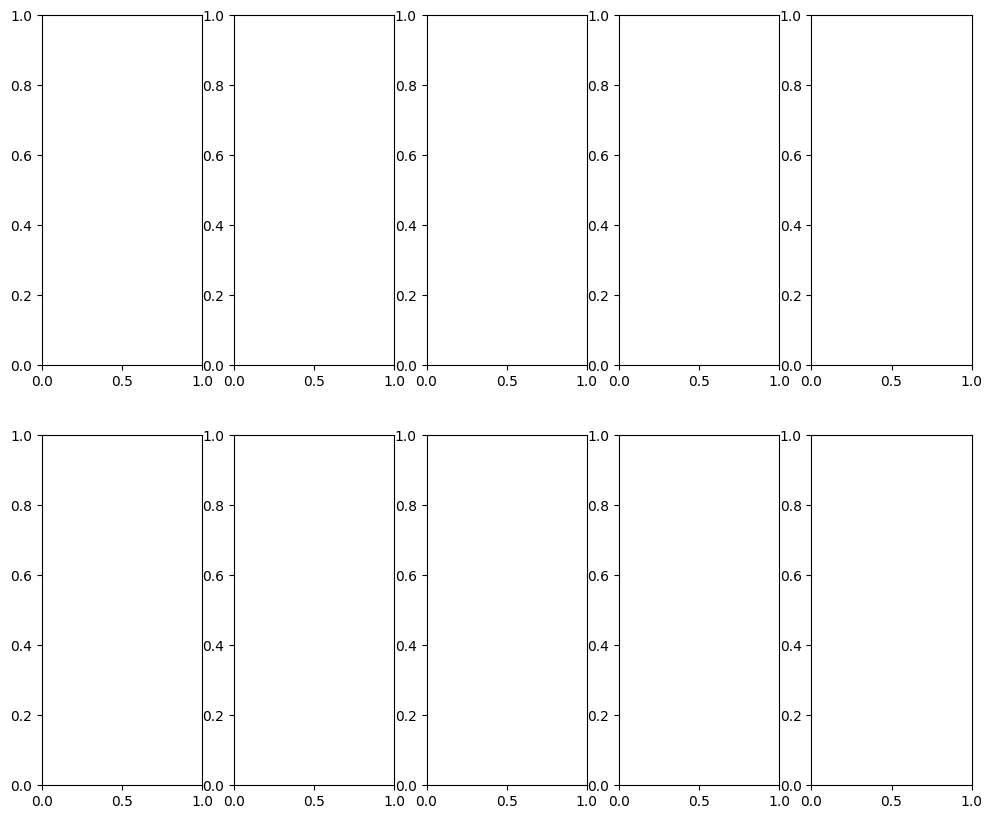

In [33]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(12, 10))
idx = 0

for i in range(2):
    for j in range(5):
        idx = np.random.randint(0, len(test_img))
        true_index = y_true_errors[idx]
        true_label = labels[true_index]
        predicted_index = y_pred_errors[idx]
        predicted_label = labels[predicted_index]
        ax[i, j].set_title(f"True Label: {true_label} \n Predicted Label: {predicted_label}")
        img_path = os.path.join(test_dataset, test_img[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax[i, j].imshow(img)
        ax[i, j].axis("off")

plt.tight_layout()
plt.suptitle('Wrong Predictions made on test set', fontsize=20)
plt.show()

In [34]:
from tensorflow.keras.models import load_model

# Save the trained model in .hdf5 format
cnn_model.save('/content/drive/MyDrive/ResNet50Trained-25.hdf5')

In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Function to predict individual image
def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Rescale the image

    prediction = loaded_model(img_array)
    predicted_class_index = np.argmax(prediction, axis=1)[0]

    target_names = ['Benign', 'Early', 'Pre', 'Pro']
    predicted_class = target_names[predicted_class_index]

    return predicted_class

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/ResNet50Trained-25.hdf5')

# Test the function
img_path = '/content/drive/MyDrive/Splitted_Dataset/test/Pro/WBC-Malignant-Pro-033.jpg'
predicted_class = predict_image(img_path, loaded_model)
print("Predicted Class: ", predicted_class)

Predicted Class:  Pro


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score, jaccard_score, log_loss, brier_score_loss, confusion_matrix, balanced_accuracy_score
import numpy as np

# Get true and predicted labels
y_true = np.array(test_generator.classes)
y_pred_probs = loaded_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Calculate metrics
accuracy = np.mean(y_true == y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Specificity, FPR, FNR, PPV, NPV for multi-class
specificity = []
fpr = []
fnr = []
ppv = []
npv = []

for i in range(len(cm)):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]

    specificity.append(tn / (tn + fp))
    fpr.append(fp / (fp + tn))
    fnr.append(fn / (fn + tp))
    ppv.append(tp / (tp + fp))
    npv.append(tn / (tn + fn))

specificity = np.mean(specificity)
fpr = np.mean(fpr)
fnr = np.mean(fnr)
ppv = np.mean(ppv)
npv = np.mean(npv)

balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
jaccard = jaccard_score(y_true, y_pred, average='macro')
log_loss_value = log_loss(y_true, y_pred_probs)

# Brier score for multi-class
brier_scores = []
for i in range(y_pred_probs.shape[1]):
    # Ensure y_true == i produces a binary array
    brier_scores.append(brier_score_loss((y_true == i).astype(int), y_pred_probs[:, i]))

brier_score = np.mean(brier_scores)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-Score: ", f1)
print("Specificity: ", specificity)
print("False Positive Rate: ", fpr)
print("False Negative Rate: ", fnr)
print("Positive Predictive Value: ", ppv)
print("Negative Predictive Value: ", npv)
print("Balanced Accuracy: ", balanced_accuracy)
print("Matthews Correlation Coefficient: ", mcc)
print("Cohen’s Kappa: ", kappa)
print("Jaccard Index: ", jaccard)
print("Log Loss: ", log_loss_value)
print("Brier Score: ", brier_score)


16/16 [==============================] - 4s 141ms/step
Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1-Score:  1.0
Specificity:  1.0
False Positive Rate:  0.0
False Negative Rate:  0.0
Positive Predictive Value:  1.0
Negative Predictive Value:  1.0
Balanced Accuracy:  1.0
Matthews Correlation Coefficient:  1.0
Cohen’s Kappa:  1.0
Jaccard Index:  1.0
Log Loss:  0.010682061720183914
Brier Score:  0.0003939155588064303


16/16 [==============================] - 2s 134ms/step


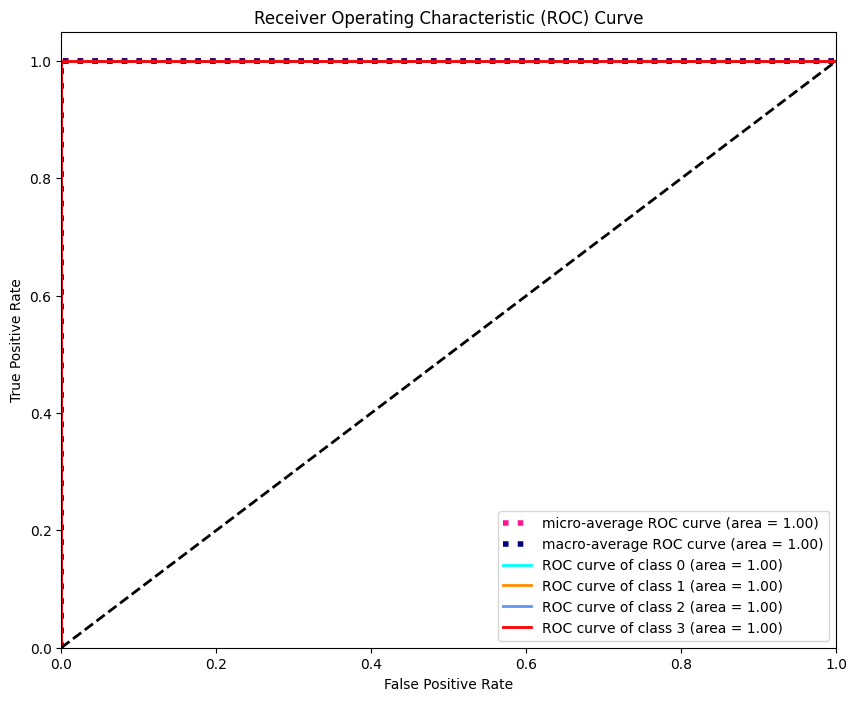

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.preprocessing import label_binarize

# Ensure that your test dataset has the correct class labels and predictions
y_true = test_generator.classes
y_pred_probs = cnn_model.predict(test_generator)

# Binarize the output
n_classes = len(test_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"], tpr["macro"], _ = roc_curve(y_true_binarized.ravel(), y_pred_probs.ravel())
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))

plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


I hope you found this notebook helpful. Suggestions are welcome.

![Upvote!](https://img.shields.io/badge/Upvote%20IF%20YOU%20LIKE%20MY%20WORK-grey?style=for-the-badge&logo=kaggle)